## DATA LOADING AND INFO

In [ ]:
#importing initial libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading the dataset

df = pd.read_csv("all_subjects_2020_final.csv")

In [ ]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127677 entries, 0 to 127676
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   post_id             127677 non-null  object 
 1   subject             127677 non-null  object 
 2   date                127677 non-null  object 
 3   title               7005 non-null    object 
 4   text                127677 non-null  object 
 5   info                127676 non-null  object 
 6   clean_text          125737 non-null  object 
 7   depression_sim      127677 non-null  float64
 8   suicide_sim         127677 non-null  float64
 9   neutral_sim         127677 non-null  float64
 10  raw_severity_score  127677 non-null  float64
 11  severity_score      127677 non-null  float64
 12  severity            127677 non-null  int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 12.7+ MB


In [ ]:
# first five rows of dataset
df.head()

In [ ]:
print(df.shape)

(127677, 13)


In [ ]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# missing values

df.isnull().sum()

,0
post_id,0
subject,0
date,0
title,120672
text,0
info,1
clean_text,1940
depression_sim,0
suicide_sim,0
neutral_sim,0


In [ ]:
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.upper() != "NAN"]

In [ ]:
df["severity"].value_counts()

,count
severity,
0,125677
1,38
2,22


## PREPROCESSING AND CLEANING

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["clean_text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

In [ ]:
depression_words = [
    "depressed","hopeless","worthless","empty",
    "cry","lonely","alone","sad","fatigue",
    "insomnia","anxiety","guilty","failure",
    "tired","helpless"
]

def depression_keyword_score(text):

    text = str(text).lower()

    return sum(word in text for word in depression_words)

df["depression_keyword"] = df["clean_text"].apply(depression_keyword_score)

In [ ]:
suicide_words = [
    "kill myself",
    "suicide",
    "want to die",
    "end my life",
    "cut myself",
    "self harm",
    "overdose",
    "hang myself",
    "jump off",
    "die"
]

def suicide_keyword_score(text):

    text = str(text).lower()

    return sum(word in text for word in suicide_words)

df["suicide_keyword"] = df["clean_text"].apply(suicide_keyword_score)

In [ ]:
df["raw_score"] = (

      0.35 * df["depression_sim"]

    + 0.35 * df["suicide_sim"]

    + 0.15 * df["depression_keyword"]

    + 0.10 * df["suicide_keyword"]

    - 0.15 * df["neutral_sim"]

    - 0.10 * df["sentiment"]

)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["severity_score"] = scaler.fit_transform(
    df[["raw_score"]]
)

In [ ]:
#dividing the severity score in two quantiles
low = df["severity_score"].quantile(0.33)

high = df["severity_score"].quantile(0.66)

def assign_severity(score):

    if score <= low:
        return 0

    elif score <= high:
        return 1

    else:
        return 2

df["severity"] = df["severity_score"].apply(assign_severity)

In [ ]:
df['severity'].value_counts()

,count
severity,
2,42751
0,41577
1,41409


In [ ]:
print(df[
[
"severity_score",
"sentiment",
"depression_keyword",
"suicide_keyword",
]
].head())

   severity_score  sentiment  depression_keyword  suicide_keyword
0        0.092580     0.4019                   0                0
1        0.140642     0.1513                   0                0
2        0.081087     0.9305                   0                0
3        0.285679     0.0000                   0                0
4        0.146477     0.4019                   0                0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = [
    "severity_score",
    "sentiment",
    "depression_keyword",
    "suicide_keyword"
]

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

In [ ]:
df[features].head(20)

,severity_score,sentiment,depression_keyword,suicide_keyword
0,0.092580,0.70095,0.0,0.0
1,0.140642,0.57565,0.0,0.0
2,0.081087,0.96525,0.0,0.0
3,0.285679,0.50000,0.0,0.0
4,0.146477,0.70095,0.0,0.0
5,0.158092,0.50000,0.0,0.0
6,0.116991,0.99825,0.0,0.0
7,0.154022,0.53860,0.0,0.0
8,0.116024,0.50000,0.0,0.0
9,0.163522,0.50000,0.0,0.0


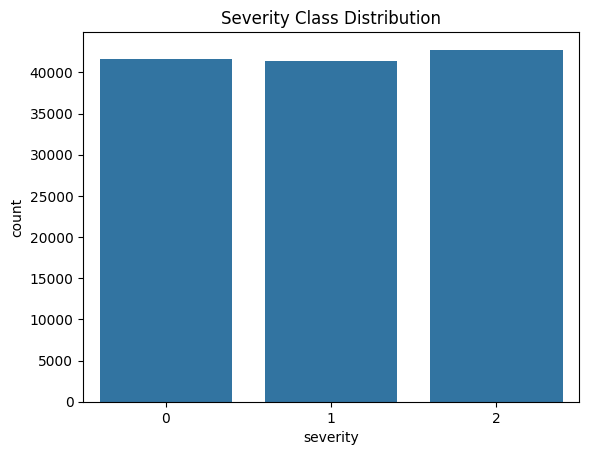

In [ ]:
#severity class

sns.countplot(x='severity',data=df)

plt.title("Severity Class Distribution")
plt.show()

Text(0.5, 1.0, 'Distribution of Reddit Post Length')

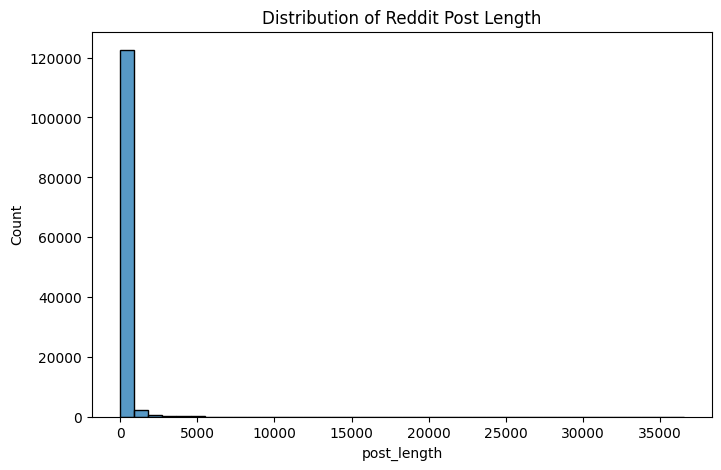

In [ ]:
# post lenght distribution

df["post_length"]=df["clean_text"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["post_length"],bins=40)

plt.title("Distribution of Reddit Post Length")

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

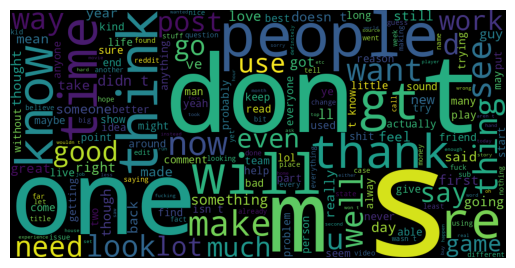

In [ ]:
#word cloud

from wordcloud import WordCloud

text=" ".join(df["clean_text"])

wordcloud=WordCloud(width=1000,height=500).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

In [ ]:
# most common words

from collections import Counter

words=" ".join(df["clean_text"]).split()

Counter(words).most_common(20)

[('the', 150130),
 ('i', 108692),
 ('to', 96785),
 ('a', 90662),
 ('and', 84828),
 ('of', 66670),
 ('it', 63385),
 ('that', 52867),
 ('you', 52637),
 ('in', 50724),
 ('is', 48747),
 ('s', 41892),
 ('for', 37201),
 ('t', 31527),
 ('this', 30551),
 ('on', 27296),
 ('but', 25445),
 ('with', 24678),
 ('my', 23553),
 ('was', 23525)]

## INTENSIVE CLEANING

In [ ]:
#lower case
df["clean_text"]=df["clean_text"].str.lower()

In [ ]:
# remove urls
import re

def remove_urls(text):
    return re.sub(r"http\S+","",text)

df["clean_text"]=df["clean_text"].apply(remove_urls)

In [ ]:
# remove punctuation
import string

def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

df["clean_text"]=df["clean_text"].apply(remove_punctuation)

In [ ]:
# remove numbers
def remove_numbers(text):
    return re.sub(r'\d+',"",text)

df["clean_text"]=df["clean_text"].apply(remove_numbers)

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# remove stopwords

from nltk.corpus import stopwords

stop_words=set(stopwords.words("english"))

df["clean_text"]=df["clean_text"].apply(
    lambda x:" ".join([w for w in x.split() if w not in stop_words])
)

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# lemmet

from nltk.stem import WordNetLemmatizer

lemmatizer=WordNetLemmatizer()

df["clean_text"]=df["clean_text"].apply(
lambda x:" ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

## LOADING OUR HUGGING FACE CREDENTIALS TO LOAD MENTAL BERT MODEL FOR BUILDING MODEL LATER

In [ ]:
from huggingface_hub import login

login("Enter you API token")

In [ ]:
# tokenize
from transformers import AutoTokenizer

tokenizer=AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased")

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## TEMPORAL FEATURE ENGINEERING AND TRAJECTORY CONSTRUCTION



In [ ]:
# create user ids

df["user_id"] = (
    df["post_id"]
    .astype(str)
    .str.split("_")
    .str[0]
)

In [ ]:
df.head()

In [ ]:
# user timeline construction

df = df.sort_values(
    ["user_id", "date"]
).reset_index(drop=True)

In [ ]:
# creating rolling severity

window_size = 5

df["rolling_severity"] = (

    df.groupby("user_id")["severity_score"]

      .transform(
          lambda x:
          x.rolling(
              window=window_size,
              min_periods=1
          ).mean()
      )

)

In [ ]:
# computing evs

df["evs"] = (

    df.groupby("user_id")["rolling_severity"]

      .diff()

      .fillna(0)

)

In [ ]:
# inspecting evs

print(df["evs"].describe())

print("Negative :", (df["evs"]<0).sum())

print("Zero :", (df["evs"]==0).sum())

print("Positive :", (df["evs"]>0).sum())

count    125737.000000
mean          0.000006
std           0.016050
min          -0.164848
25%          -0.009393
50%           0.000000
75%           0.009423
max           0.211808
Name: evs, dtype: float64
Negative : 62295
Zero : 827
Positive : 62615


In [ ]:
print(df["evs"].describe())

print("Negative EVS :", (df["evs"] < 0).sum())
print("Zero EVS :", (df["evs"] == 0).sum())
print("Positive EVS :", (df["evs"] > 0).sum())

count    125737.000000
mean          0.000006
std           0.016050
min          -0.164848
25%          -0.009393
50%           0.000000
75%           0.009423
max           0.211808
Name: evs, dtype: float64
Negative EVS : 62295
Zero EVS : 827
Positive EVS : 62615


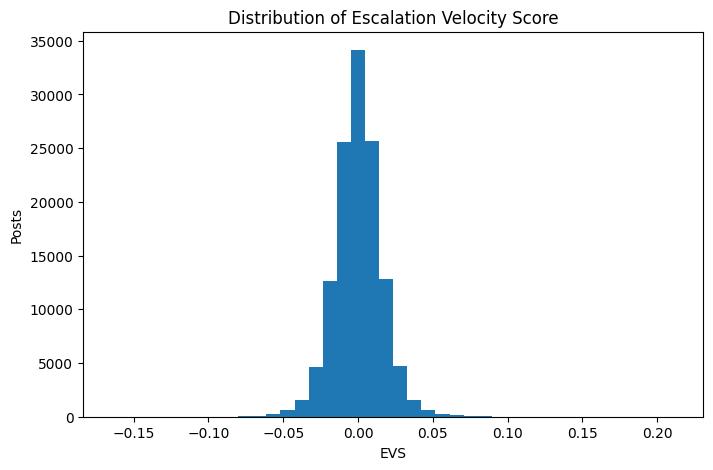

In [ ]:
# hist plot for distribution of Escalation Velocity Score

plt.figure(figsize=(8,5))

plt.hist(
    df["evs"],
    bins=40
)

plt.title("Distribution of Escalation Velocity Score")

plt.xlabel("EVS")

plt.ylabel("Posts")

plt.show()

In [ ]:
# creating trajectory labels

low = df["evs"].quantile(0.33)
high = df["evs"].quantile(0.67)

print(low)
print(high)

-0.006014009146566243
0.006024443093967547


In [ ]:
def assign_trajectory(evs):

    if evs <= low:
        return "Recovering"

    elif evs >= high:
        return "Escalating"

    else:
        return "Stable"

df["trajectory"] = df["evs"].apply(assign_trajectory)

In [ ]:
print(df["trajectory"].value_counts())

trajectory
Stable        42751
Recovering    41493
Escalating    41493
Name: count, dtype: int64


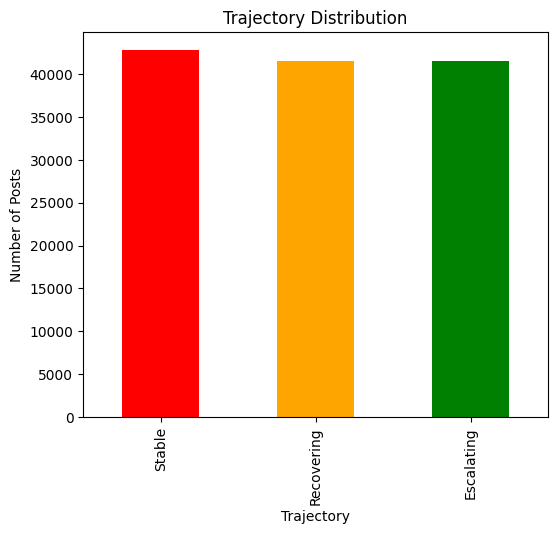

In [ ]:
# trajectory distribution


plt.figure(figsize=(6,5))

df["trajectory"].value_counts().plot(
    kind="bar",
    color=["red","orange","green"]
)

plt.title("Trajectory Distribution")
plt.xlabel("Trajectory")
plt.ylabel("Number of Posts")

plt.show()

In [ ]:
# creating final dataset for Models

trajectory_df = df[[
    "user_id",
    "clean_text",
    "date",
    "severity_score",
    "sentiment",
    "depression_keyword",
    "suicide_keyword",
    "evs",
    "trajectory"
]].copy()

In [ ]:
trajectory_df.head()

## EDA - EXPLORATORY DATA ANALYSIS

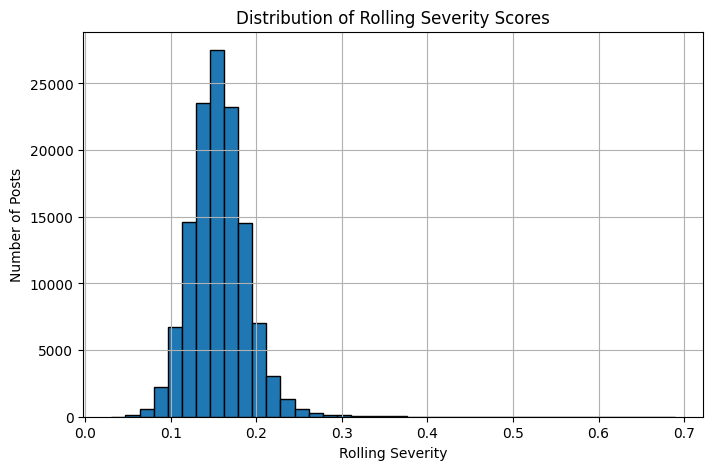

In [ ]:
# rolling severity

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["rolling_severity"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Rolling Severity")
plt.ylabel("Number of Posts")
plt.title("Distribution of Rolling Severity Scores")

plt.grid(True)

plt.show()

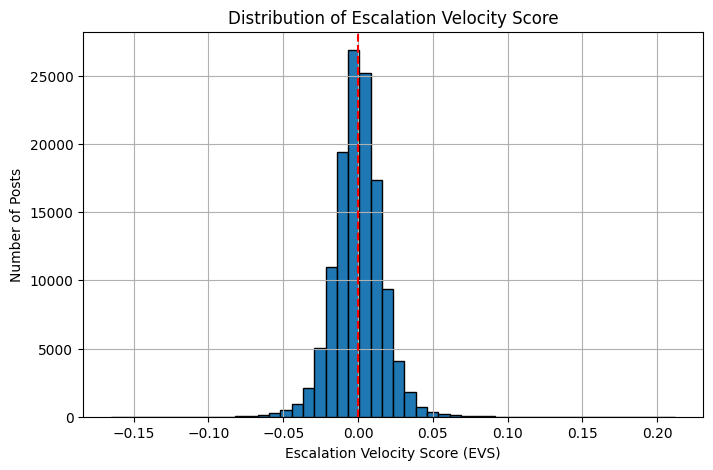

In [ ]:
# EVS distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["evs"],
    bins=50,
    edgecolor="black"
)

plt.axvline(0,color="red",linestyle="--")

plt.xlabel("Escalation Velocity Score (EVS)")
plt.ylabel("Number of Posts")
plt.title("Distribution of Escalation Velocity Score")

plt.grid(True)

plt.show()

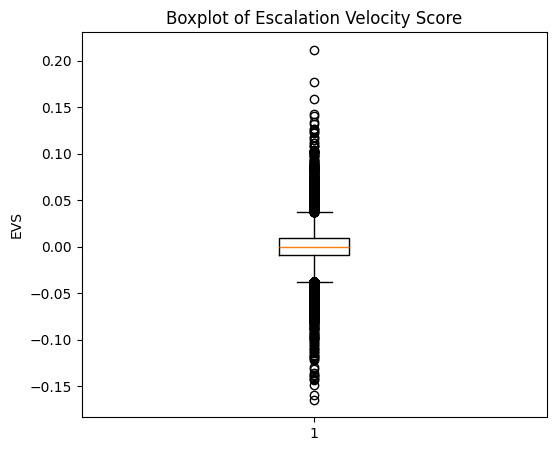

In [ ]:
# evs boxplot

plt.figure(figsize=(6,5))

plt.boxplot(df["evs"])

plt.title("Boxplot of Escalation Velocity Score")

plt.ylabel("EVS")

plt.show()

trajectory
Stable        42751
Recovering    41493
Escalating    41493
Name: count, dtype: int64


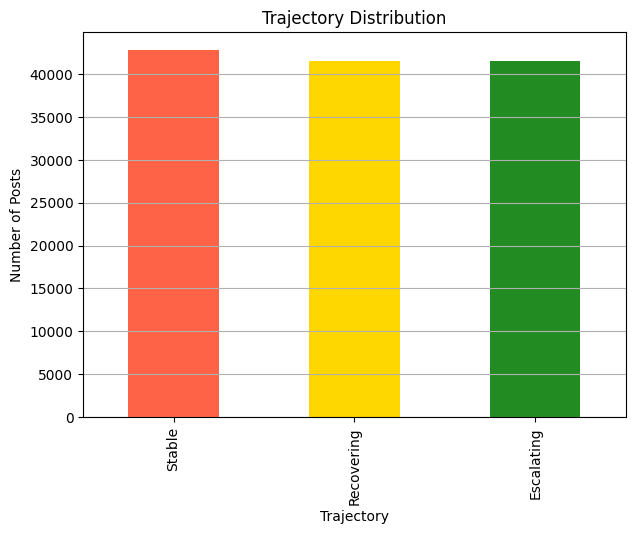

In [ ]:
# trajectory distribution

trajectory_counts = df["trajectory"].value_counts()

print(trajectory_counts)

plt.figure(figsize=(7,5))

trajectory_counts.plot(
    kind="bar",
    color=["tomato","gold","forestgreen"]
)

plt.xlabel("Trajectory")

plt.ylabel("Number of Posts")

plt.title("Trajectory Distribution")

plt.grid(axis="y")

plt.show()

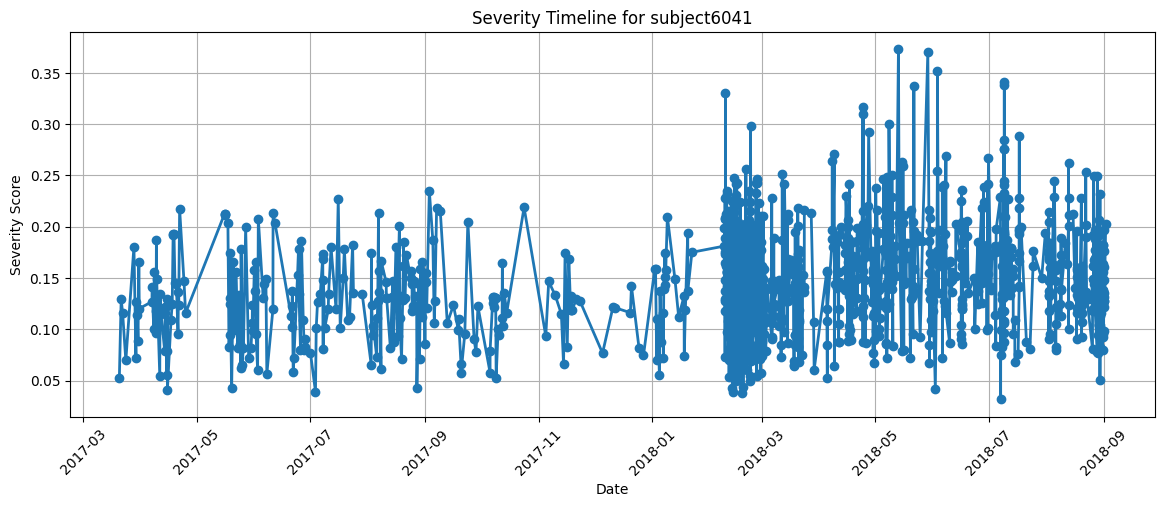

In [ ]:
# timeline of sample user

sample_user = df["user_id"].value_counts().index[0]

user_df = df[df["user_id"] == sample_user]

plt.figure(figsize=(14,5))

plt.plot(
    user_df["date"],
    user_df["severity_score"],
    marker="o",
    linewidth=2
)

plt.title(f"Severity Timeline for {sample_user}")

plt.xlabel("Date")

plt.ylabel("Severity Score")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

count     340.000000
mean      369.814706
std       373.807569
min         1.000000
25%        54.000000
50%       212.500000
75%       621.250000
max      1342.000000
dtype: float64


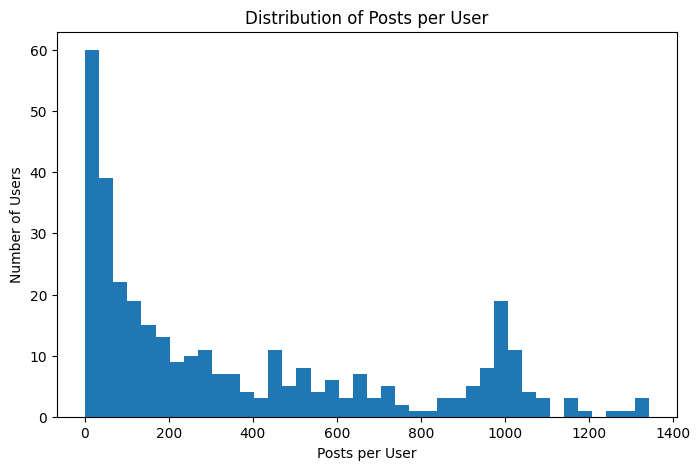

In [ ]:
# posts per user

posts_per_user = df.groupby("user_id").size()

print(posts_per_user.describe())

plt.figure(figsize=(8,5))

plt.hist(
    posts_per_user,
    bins=40
)

plt.xlabel("Posts per User")

plt.ylabel("Number of Users")

plt.title("Distribution of Posts per User")

plt.show()

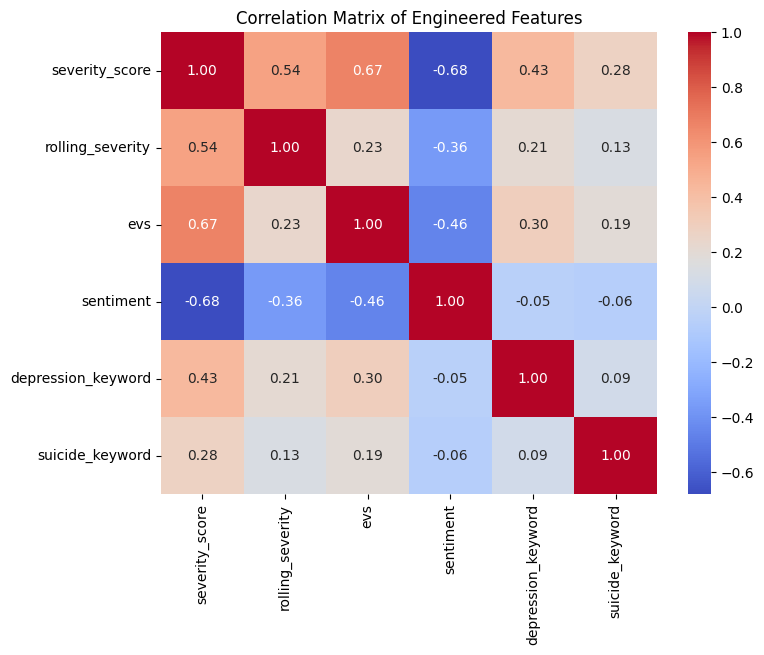

In [ ]:
# correlation between features

import seaborn as sns

features = [

    "severity_score",

    "rolling_severity",

    "evs",

    "sentiment",

    "depression_keyword",

    "suicide_keyword"

]

plt.figure(figsize=(8,6))

sns.heatmap(

    df[features].corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Matrix of Engineered Features")

plt.show()

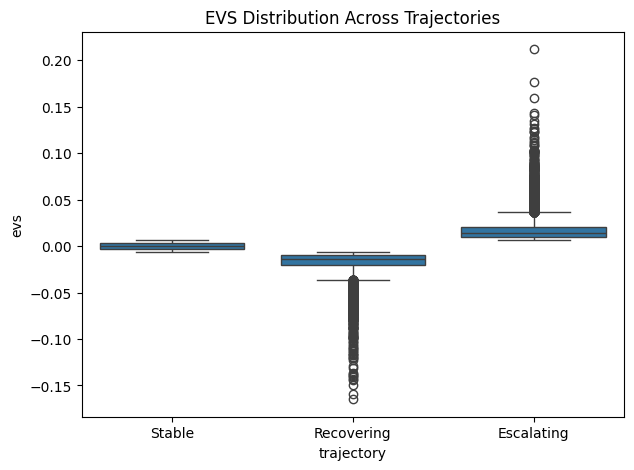

In [ ]:
# evs by trajectory

plt.figure(figsize=(7,5))

sns.boxplot(

    x="trajectory",

    y="evs",

    data=df

)

plt.title("EVS Distribution Across Trajectories")

plt.show()

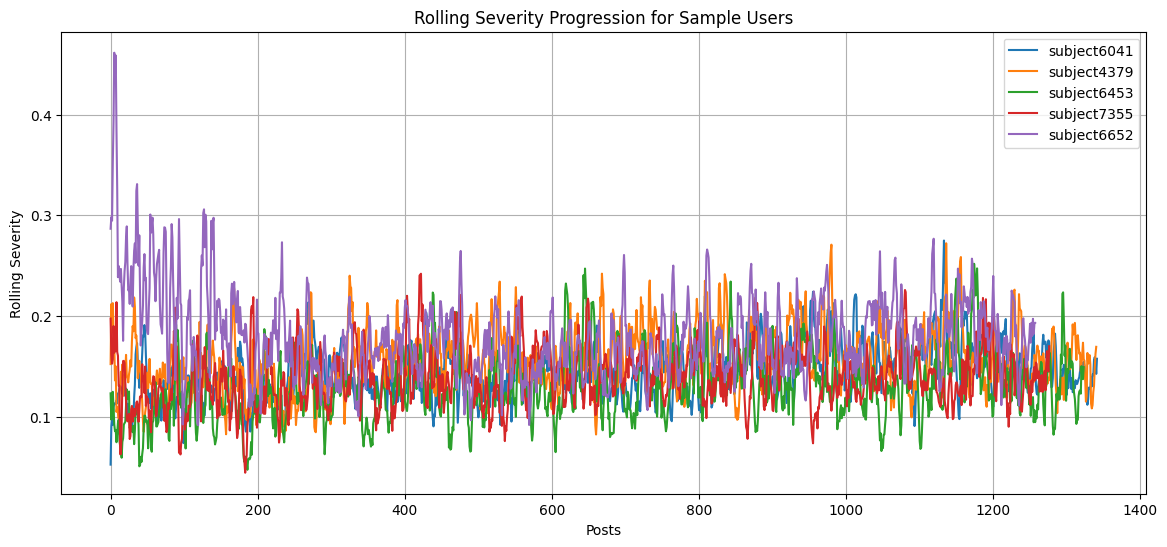

In [ ]:
# rolling severity overtime (multiple users)

top_users = df["user_id"].value_counts().head(5).index

plt.figure(figsize=(14,6))

for user in top_users:

    user_df = df[df["user_id"] == user]

    plt.plot(
        user_df["rolling_severity"].values,
        label=user
    )

plt.legend()

plt.xlabel("Posts")

plt.ylabel("Rolling Severity")

plt.title("Rolling Severity Progression for Sample Users")

plt.grid(True)

plt.show()

## BASELINE 1 - LOGISTIC REGRESSION + TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

In [ ]:
# preparing dataset

X_text = trajectory_df["clean_text"]

encoder = LabelEncoder()

y = encoder.fit_transform(
    trajectory_df["trajectory"]
)

In [ ]:
# TF-IDF

vectorizer = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1,2),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True

)

X = vectorizer.fit_transform(X_text)

In [ ]:
# train/test/split

X_train_lr,\
X_test_lr,\
y_train_lr,\
y_test_lr = train_test_split(

    X,

    y,

    stratify=y,

    test_size=0.20,

    random_state=42

)

In [ ]:
lr_model = LogisticRegression(

    max_iter=3000,

    class_weight="balanced",

    random_state=42

)

lr_model.fit(

    X_train_lr,

    y_train_lr


)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)

In [ ]:
# PRED

lr_pred = lr_model.predict(X_test_lr)

In [ ]:
#EVAL

lr_accuracy = accuracy_score(

    y_test_lr,

    lr_pred

)

print("Accuracy :", lr_accuracy)

print()

print(

classification_report(

    y_test_lr,

    lr_pred,

    target_names=encoder.classes_

)

)

Accuracy : 0.47387466200095435

              precision    recall  f1-score   support

  Escalating       0.53      0.53      0.53      8299
  Recovering       0.49      0.53      0.51      8299
      Stable       0.40      0.37      0.38      8550

    accuracy                           0.47     25148
   macro avg       0.47      0.47      0.47     25148
weighted avg       0.47      0.47      0.47     25148



In [ ]:
lr_accuracy = print("Accuracy :", lr_accuracy)

Accuracy : 0.47387466200095435


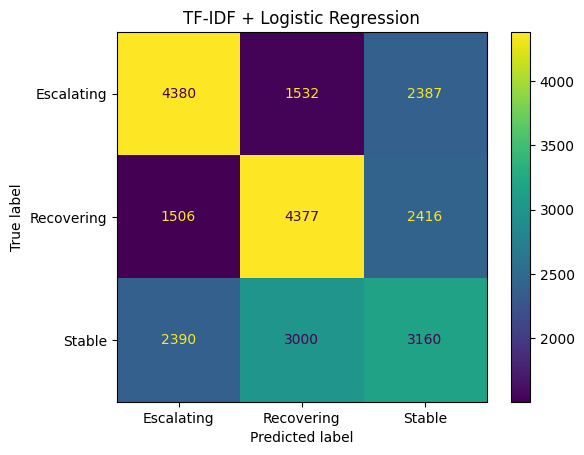

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(

    y_test_lr,

    lr_pred

)

ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_

).plot()

plt.title("TF-IDF + Logistic Regression")

plt.show()

In [ ]:
# shap

import shap

In [ ]:
# feature names

feature_names = list(vectorizer.get_feature_names_out())

print("Vocabulary Size:", len(feature_names))

Vocabulary Size: 10000


In [ ]:
#create explainer

explainer = shap.LinearExplainer(
    lr_model,
    X_train_lr
)

In [ ]:
# computing shap on approx 1000 samples

sample_size = min(1000, X_test_lr.shape[0])

X_sample = X_test_lr[:sample_size]

shap_values = explainer(X_sample)

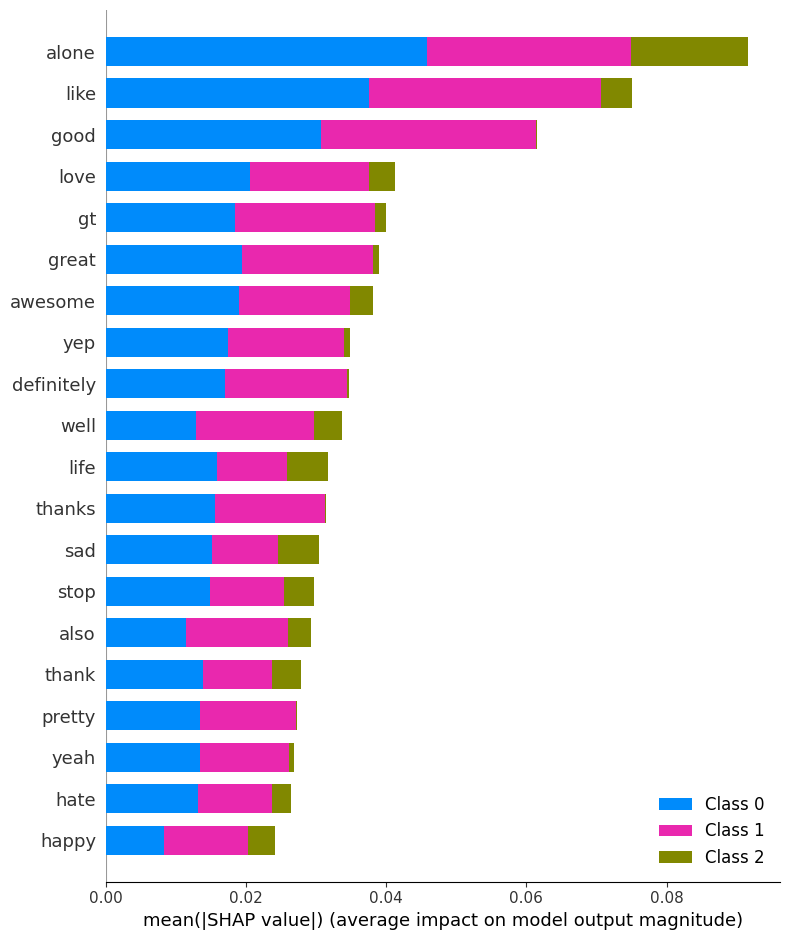

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=vectorizer.get_feature_names_out()
)

## BASELINE 2 MENTAL BERT

In [ ]:
#Import libraries

import torch

from transformers import (

AutoTokenizer,

AutoModelForSequenceClassification,

Trainer,

TrainingArguments

)

from datasets import Dataset

In [ ]:
# Sample 20% while preserving trajectory distribution

bert_df, _ = train_test_split(
    trajectory_df,
    train_size=0.20,
    stratify=trajectory_df["trajectory"],
    random_state=42
)

print(bert_df["trajectory"].value_counts())

trajectory
Stable        8550
Recovering    8299
Escalating    8298
Name: count, dtype: int64


In [ ]:
train_df, test_df = train_test_split(
    bert_df,
    test_size=0.20,
    stratify=bert_df["trajectory"],
    random_state=42
)

In [ ]:
# encode
encoder = LabelEncoder()

bert_df["label"] = encoder.fit_transform(

    bert_df["trajectory"]

)

In [ ]:
#train/test/split

train_df,\
test_df = train_test_split(

    bert_df,

    stratify=bert_df["label"],

    random_state=42,

    test_size=0.20

)

In [ ]:
# model

model_name = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

In [ ]:
#tokenize

def tokenize(batch):

    return tokenizer(

        batch["clean_text"],

        padding="max_length",

        truncation=True,

        max_length=128

    )

In [ ]:
# dataset

train_dataset = Dataset.from_pandas(
    train_df
)

test_dataset = Dataset.from_pandas(
    test_df
)

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/20117 [00:00<?, ? examples/s]

Map:   0%|          | 0/5030 [00:00<?, ? examples/s]

In [ ]:
# initializing the mental bert

model = AutoModelForSequenceClassification.from_pretrained(

    model_name,

    num_labels=3

)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

In [ ]:
#training args


training_args = TrainingArguments(

    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_steps=100

)

In [ ]:
#trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset

)

In [ ]:
# train

trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch,Training Loss,Validation Loss
1,1.013107,0.999985
2,0.879629,1.060411
3,0.654823,1.275228


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3774, training_loss=0.8644693179552556, metrics={'train_runtime': 1458.3019, 'train_samples_per_second': 41.384, 'train_steps_per_second': 2.588, 'total_flos': 3969789468325632.0, 'train_loss': 0.8644693179552556, 'epoch': 3.0})

In [ ]:
# Evaluating

predictions = trainer.predict(
    test_dataset
)

pred = np.argmax(

    predictions.predictions,

    axis=1

)

y_true = test_df["label"]

print(

classification_report(

    y_true,

    pred,

    target_names=encoder.classes_

)

)

              precision    recall  f1-score   support

  Escalating       0.55      0.51      0.53      1660
  Recovering       0.53      0.45      0.49      1660
      Stable       0.39      0.47      0.43      1710

    accuracy                           0.48      5030
   macro avg       0.49      0.48      0.48      5030
weighted avg       0.49      0.48      0.48      5030



In [ ]:
print("accuracy:", accuracy_score(y_true, pred))

accuracy: 0.47773359840954277


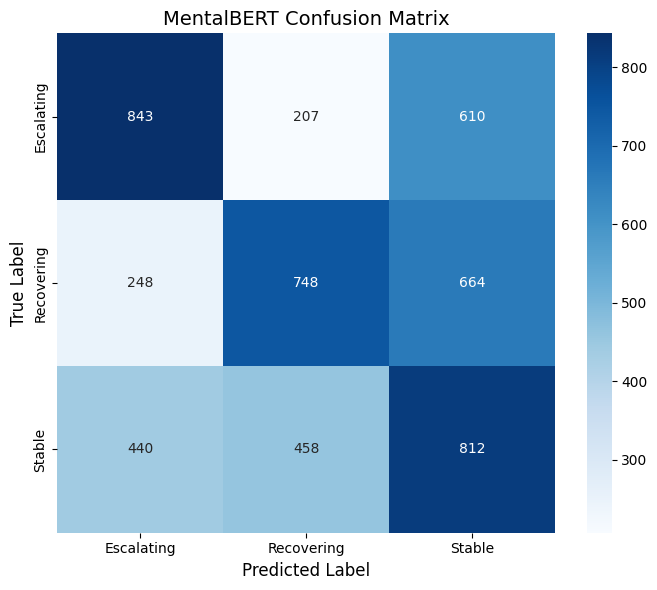

In [ ]:
#confusion matrix

cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("MentalBERT Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

LSTM

In [ ]:
# Import libraries

import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

In [ ]:
# selecting features

features = [

    "severity_score",

    "sentiment",

    "depression_keyword",

    "suicide_keyword",

    "evs"

]

In [ ]:
# encoding labels
encoder = LabelEncoder()

trajectory_df["trajectory_label"] = encoder.fit_transform(
    trajectory_df["trajectory"]
)

print(encoder.classes_)

['Escalating' 'Recovering' 'Stable']


In [ ]:
# creating temporal sequences

sequence_length = 10

X = []
y = []

for user in trajectory_df["user_id"].unique():

    user_df = trajectory_df[
        trajectory_df["user_id"] == user
    ]

    user_df = user_df.sort_values("date")

    values = user_df[features].values

    labels = user_df["trajectory_label"].values

    if len(values) < sequence_length:
        continue

    for i in range(len(values)-sequence_length):

        X.append(
            values[i:i+sequence_length]
        )

        y.append(
            labels[i+sequence_length]
        )

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(122379, 10, 5)
(122379,)


In [ ]:
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [ ]:
# one hot enoding
y_train_cat = to_categorical(y_train_ls)

y_test_cat = to_categorical(y_test_ls)

In [ ]:
# evs+lstm

model = Sequential()

model.add(

    LSTM(

        64,

        input_shape=(
            sequence_length,
            len(features)
        )

    )

)

model.add(

    Dropout(0.30)

)

model.add(

    Dense(
        32,
        activation="relu"
    )

)

model.add(

    Dropout(0.20)

)

model.add(

    Dense(
        3,
        activation="softmax"
    )

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# compile

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,099 (78.51 KB)

 Trainable params: 20,099 (78.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    verbose=1

)

history = model.fit(

    X_train_ls,

    y_train_cat,

    validation_split=0.20,

    epochs=30,

    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1

)

Epoch 1/30
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5847 - loss: 0.8589 - val_accuracy: 0.5911 - val_loss: 0.8467 - learning_rate: 7.8125e-06
Epoch 2/30
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5843 - loss: 0.8579 - val_accuracy: 0.5912 - val_loss: 0.8467 - learning_rate: 7.8125e-06
Epoch 3/30
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5849 - loss: 0.8588 - val_accuracy: 0.5904 - val_loss: 0.8465 - learning_rate: 7.8125e-06
Epoch 4/30
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5846 - loss: 0.8589 - val_accuracy: 0.5915 - val_loss: 0.8466 - learning_rate: 7.8125e-06
Epoch 5/30
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5854 - loss: 0.8581 - val_accuracy: 0.5920 - val_loss: 0.8466 - learning_rate: 7.8125e-06
Epoch 6/30
1218/1224 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5839 - loss: 0.8568
Epoch 6: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/ste

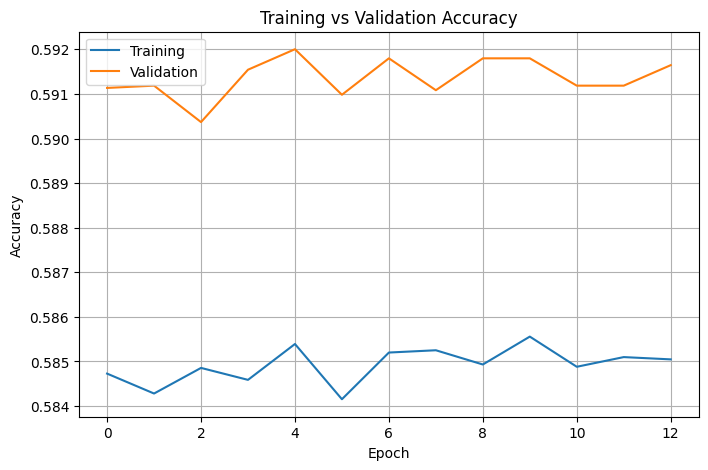

In [ ]:
# accuracy plot

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

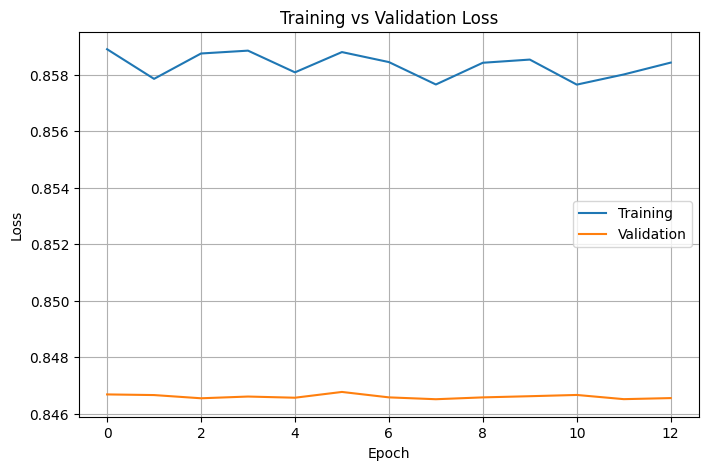

In [ ]:
#loss plot

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# pred

pred_prob = model.predict(X_test_ls)

pred = np.argmax(pred_prob, axis=1)

765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [ ]:
# eval

print("Accuracy :", accuracy_score(y_test_ls, pred))
a
print()

print(classification_report(
    y_test_ls,
    pred,
    target_names=encoder.classes_
))

Accuracy : 0.5856757640137278

              precision    recall  f1-score   support

  Escalating       0.65      0.61      0.63      8087
  Recovering       0.66      0.67      0.67      8089
      Stable       0.46      0.48      0.47      8300

    accuracy                           0.59     24476
   macro avg       0.59      0.59      0.59     24476
weighted avg       0.59      0.59      0.59     24476



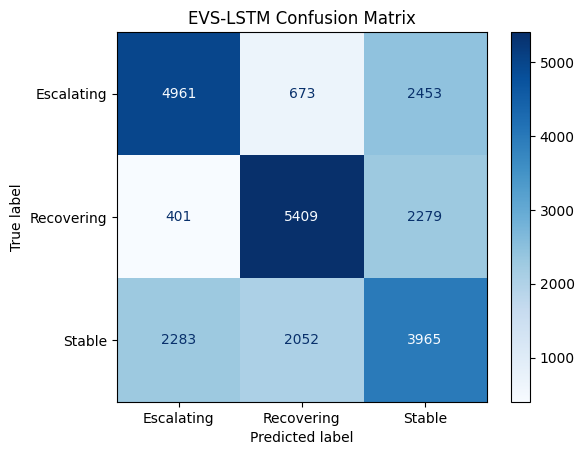

In [ ]:
# confusion matrix

cm = confusion_matrix(y_test_ls, pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_

)

disp.plot(cmap="Blues")

plt.title("EVS-LSTM Confusion Matrix")

plt.show()

In [ ]:
# creating the explainer

explainer = shap.GradientExplainer(
    model,
    background
)

In [ ]:
#shape vals
shap_values = explainer.shap_values(X_sample)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 10, 5))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 10, 5))']
  warnings.warn(msg)


In [ ]:
# average over classes

sv_all = shap_values.mean(axis=3)
print(sv_all)

[[[-6.98491931e-10 -1.94025536e-11  4.12304265e-11  4.36557457e-11
    1.94025536e-11]
  [ 7.76102146e-11 -1.94025536e-11  0.00000000e+00 -1.09139364e-11
   -3.88051073e-10]
  [-3.10440858e-10  3.88051073e-11 -5.82076609e-11  4.85063841e-11
   -1.55220429e-09]
  ...
  [-2.32830644e-10 -1.50369791e-10  6.06329801e-12  3.88051073e-11
   -1.24297609e-11]
  [ 1.45519152e-11 -1.21265960e-10  2.66785113e-11  3.63797881e-12
    8.73114914e-11]
  [ 1.55220429e-09 -5.82076609e-11 -4.85063841e-12 -9.70127682e-12
    3.88051073e-11]]

 [[-1.15202662e-11 -8.00355338e-11 -3.88051073e-11 -4.12304265e-11
    5.82076609e-11]
  [ 1.24176343e-09 -9.70127682e-12  0.00000000e+00 -5.51760119e-11
    1.35817875e-10]
  [-4.65661287e-10  1.74622983e-10 -9.70127682e-12  3.75924477e-11
    8.60988318e-11]
  ...
  [-7.76102146e-10  5.82076609e-11 -1.94025536e-11  1.16415322e-10
   -1.35817875e-10]
  [ 2.48352687e-09  1.16415322e-10 -1.94025536e-11 -3.88051073e-11
   -4.85063841e-11]
  [-6.98491931e-10 -4.4004385

In [ ]:
# average over time stamps
sv_all = sv_all.mean(axis=1)

In [ ]:
# input data
X_plot = X_sample.mean(axis=1)

In [ ]:
#feature names
feature_names = [
    "Severity Score",
    "Sentiment",
    "Depression Keyword",
    "Suicide Keyword",
    "EVS"
]

/tmp/ipykernel_434/615314128.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


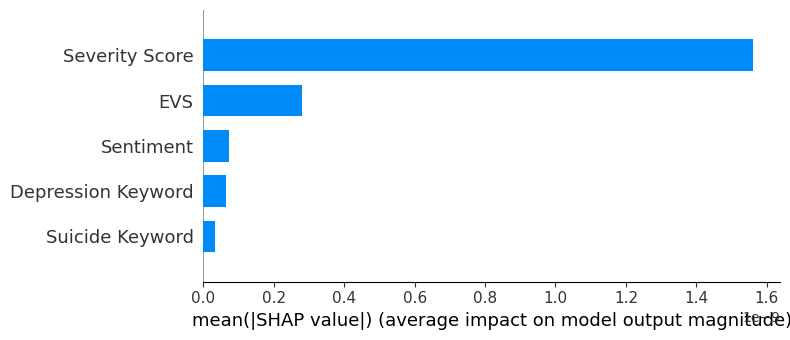

In [ ]:
#global importance plot
shap.summary_plot(
    sv_all,
    X_plot,
    feature_names=feature_names,
    plot_type="bar"
)

/tmp/ipykernel_434/2534990891.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


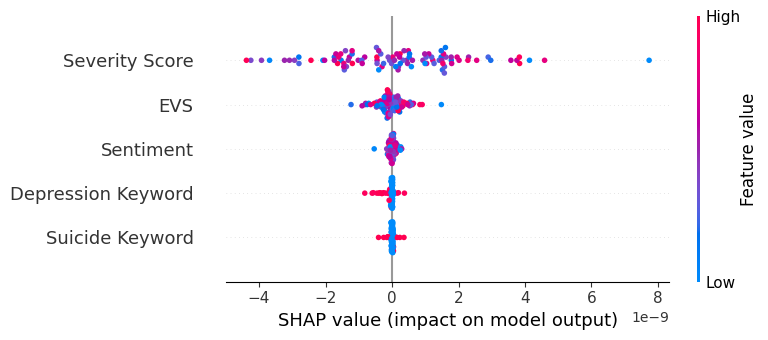

In [ ]:
# beeswarm plot
shap.summary_plot(
    sv_all,
    X_plot,
    feature_names=feature_names
)